# 02 · Cleaning & EDA

**Input:** `data/raw/rdu_ghcnh_2015-01-01_to_2026-09-16.csv` (NOAA) and `data/raw/ecmwf_ifs_runs_2024-03-14_to_2026-09-16.csv` (ECMWF), both from `01`.
**Output:** `data/interim/rdu_temperature_clean_2015-01-01_to_2026-09-16.csv`, one row per UTC hour with the cleaned temperature.

The model uses only the station's temperature (as the target and for recent anomalies), so cleaning focuses on temperature; dew point and pressure are read only to detect corrupted reports. ECMWF output is model data and is used as published.

## 1. Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
RAW_NOAA = PROJECT_ROOT / "data" / "raw" / "rdu_ghcnh_2015-01-01_to_2026-09-16.csv"
RAW_ECMWF = PROJECT_ROOT / "data" / "raw" / "ecmwf_ifs_runs_2024-03-14_to_2026-09-16.csv"
CLEAN_FILE = PROJECT_ROOT / "data" / "interim" / "rdu_temperature_clean_2015-01-01_to_2026-09-16.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

NY = "America/New_York"
START = pd.Timestamp("2015-01-01", tz=NY)
CUTOFF = pd.Timestamp("2026-09-17", tz=NY)  # first hour that must NOT be used


def save_fig(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"02_{name}.png", dpi=150, bbox_inches="tight")

## 2. Load and build the hourly grid

- Each report is taken at minute :51 and labelled with the UTC hour it belongs to (00:51 → hour 00).
- Hours without any report become empty rows, so that "one row back" always means "one hour back".

In [ ]:
# 温度，露点，气压
VARIABLES = ["temperature", "dew_point_temperature", "altimeter"]  # dew point and pressure only help detect bad reports
# 给 温度，露点，气压 加上自己的 质量码，也就是 NOAA 自己标注的"这个值可不可靠"， 加上时间最后
columns = ["DATE"] + [f"{v}{suffix}" for v in VARIABLES for suffix in ("", "_Source_Code", "_Quality_Code")]
raw = pd.read_csv(RAW_NOAA, usecols=columns, dtype=str, keep_default_na=False)

observation_utc = pd.to_datetime(raw["DATE"], utc=True)
assert observation_utc.is_unique and observation_utc.dt.minute.eq(51).all()
raw.index = pd.DatetimeIndex(observation_utc.dt.floor("h"), name="hour_utc")  # the report at hh:51 is labelled hh

grid = pd.date_range(START.tz_convert("UTC"), CUTOFF.tz_convert("UTC"), freq="h", inclusive="left", name="hour_utc")
obs = raw.reindex(grid)  # hours without a report become empty rows
for v in VARIABLES:
    obs[v] = pd.to_numeric(obs[v].replace("", np.nan), errors="coerce")

missing = grid.difference(raw.index)
gap_id = (missing.to_series().diff() != pd.Timedelta(hours=1)).cumsum()
gap_lengths = missing.to_series().groupby(gap_id.to_numpy()).size()
print(f"Hourly grid: {len(grid):,} hours ({grid[0].tz_convert(NY):%Y-%m-%d %H:%M} -> {grid[-1].tz_convert(NY):%Y-%m-%d %H:%M} Eastern)")
print(f"Reports: {len(raw):,}; hours with no report: {len(missing)} in {len(gap_lengths)} gaps (longest {gap_lengths.max()} h)")

Hourly grid: 102,647 hours (2015-01-01 00:00 -> 2026-09-16 23:00 Eastern)
Reports: 102,471; hours with no report: 176 in 59 gaps (longest 90 h)


## 3. Clean the temperature

Fixed rules, set in advance (nothing is tuned on the data):

| Rule | Rejects |
|---|---|
| Quality codes | values the source marks as suspect or erroneous (ISD sources: 2, 3, 6, 7; legacy sources: 2, 3, 5; any lowercase GHCNh check flag) |
| Physical limits | temperatures outside −30 … 45 °C |
| Corrupted report | hours where at least two of temperature (> 4 °C), dew point (> 5 °C) and pressure (> 3 hPa) jump and immediately return |
| One-hour spike | temperature jumps of more than 8 °C that immediately return |

Rejected values become `NaN`; the original value is kept in `temperature_raw`. Missing temperatures are not interpolated. The most recent source (413, since March 2026) supplies no quality codes, so the physical checks are its only safeguard.

In [3]:
ISD_SOURCES = {"313", "314", "315", "322", "335", "343", "344", "346"}
LEGACY_SOURCES = {"220", "221", "222", "223", "347", "348"}
LIMITS = {"temperature": (-30, 45), "dew_point_temperature": (-40, 35), "altimeter": (950, 1060)}


def code(series):
    return series.fillna("").astype(str).str.replace(r"\.0$", "", regex=True)


def bad_quality(v):
    """Source-specific quality codes (GHCNh documentation, Section VI)."""
    source, quality = code(obs[f"{v}_Source_Code"]), code(obs[f"{v}_Quality_Code"])
    return ((source.isin(ISD_SOURCES) & quality.isin({"2", "3", "6", "7"}))
            | (source.isin(LEGACY_SOURCES) & quality.isin({"2", "3", "5"}))
            | quality.str.contains(r"[a-z]", regex=True))


def spike_size(x):
    """Size of a one-hour jump that reverses in the next hour (0 otherwise)."""
    jump_in, jump_out = x - x.shift(1), x - x.shift(-1)
    return np.minimum(jump_in.abs(), jump_out.abs()).where(np.sign(jump_in) == np.sign(jump_out), 0)


# Step 1: quality codes and physical limits, for all three variables
screened = pd.DataFrame({v: obs[v].mask(bad_quality(v) | ~obs[v].between(*LIMITS[v])) for v in VARIABLES})
# Step 2: spikes, measured on the screened values
corrupted_report = ((spike_size(screened["temperature"]) > 4).astype(int)
                    + (spike_size(screened["dew_point_temperature"]) > 5).astype(int)
                    + (spike_size(screened["altimeter"]) > 3).astype(int)) >= 2

t = obs["temperature"]
reasons = pd.DataFrame({
    "quality code": bad_quality("temperature"),
    "outside -30..45 deg C": ~t.between(*LIMITS["temperature"]),
    "corrupted report (2+ variables spike)": corrupted_report,
    "one-hour spike > 8 deg C": spike_size(screened["temperature"]) > 8,
}).astype(bool).mul(t.notna(), axis=0)
rejected = reasons.any(axis=1)

clean = pd.DataFrame({
    "hour_local": grid.tz_convert(NY).strftime("%Y-%m-%d %H:%M"),
    "temperature": t.mask(rejected),
    "temperature_raw": t,
}, index=grid)
display(reasons.sum().rename("temperatures rejected").to_frame())
display(pd.DataFrame({"hour_local": clean.loc[rejected, "hour_local"],
                      "previous hour": t.shift(1)[rejected], "rejected value": t[rejected], "next hour": t.shift(-1)[rejected],
                      "reason": reasons[rejected].idxmax(axis=1)}).reset_index(drop=True))

,temperatures rejected
quality code,8
outside -30..45 deg C,0
corrupted report (2+ variables spike),1
one-hour spike > 8 deg C,0


,hour_local,previous hour,rejected value,next hour,reason
0,2019-03-01 11:00,5.0,9.4,5.0,corrupted report (2+ variables spike)
1,2024-12-27 05:00,4.4,4.0,4.4,quality code
2,2024-12-27 06:00,4.0,4.4,5.0,quality code
3,2024-12-28 08:00,8.3,9.0,12.0,quality code
4,2024-12-28 09:00,9.0,12.0,14.4,quality code
5,2025-01-29 06:00,2.8,3.3,3.9,quality code
6,2025-02-07 10:00,16.7,19.0,20.6,quality code
7,2025-03-16 20:00,21.7,22.0,20.0,quality code
8,2025-03-23 09:00,10.0,15.6,17.2,quality code


## 4. Checks and export

In [4]:
checks = {
    "continuous hourly grid": clean.index.equals(grid),
    "nothing at/after 12am Sep 17": clean.index.max() < CUTOFF,
    "kept temperatures are unchanged": clean["temperature"].dropna().equals(clean["temperature_raw"][clean["temperature"].notna()]),
    "missing = no report + rejected": clean["temperature"].isna().sum() == len(missing) + rejected.sum(),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())

CLEAN_FILE.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(CLEAN_FILE, index_label="hour_utc")
print(f"Saved {CLEAN_FILE.relative_to(PROJECT_ROOT)}: {len(clean):,} hours, "
      f"{clean['temperature'].notna().sum():,} usable temperatures")

,passed
continuous hourly grid,True
nothing at/after 12am Sep 17,True
kept temperatures are unchanged,True
missing = no report + rejected,True


Saved data/interim/rdu_temperature_clean_2015-01-01_to_2026-09-16.csv: 102,647 hours, 102,462 usable temperatures


## 5. EDA

### 5.1 Seasonal and daily cycle

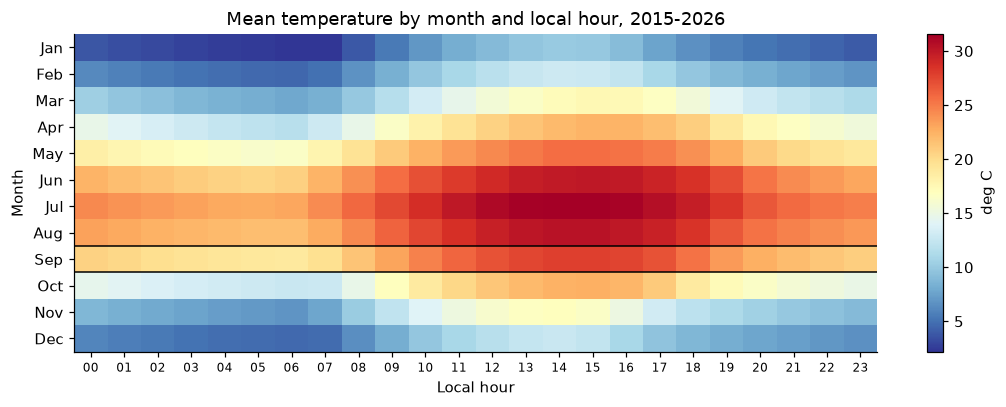

In [10]:
local = clean.index.tz_convert(NY)
month_hour = clean.groupby([local.month, local.hour])["temperature"].mean().unstack()
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 3.8))
image = ax.imshow(month_hour.to_numpy(), aspect="auto", cmap="RdYlBu_r")
ax.set_xticks(range(24), [f"{h:02d}" for h in range(24)], fontsize=8)
ax.set_yticks(range(12), months)
for edge in (7.5, 8.5):  # outline September
    ax.axhline(edge, color="black", linewidth=1)
ax.set(title="Mean temperature by month and local hour, 2015-2026", xlabel="Local hour", ylabel="Month")
fig.colorbar(image, ax=ax, label="deg C")
fig.tight_layout()
save_fig(fig, "month_hour_heatmap")
plt.show()

### 5.2 How long does the station remember the weather?

The anomaly is the temperature minus the average for that day of year and local hour (smoothed over ±7 days). Its correlation with later values shows how far ahead the station's own history can help a forecast.

                        1 days  3 days  5 days  7 days  14 days
temperature               0.89    0.78    0.76    0.75     0.74
anomaly (weather only)    0.57    0.16    0.08    0.06     0.07


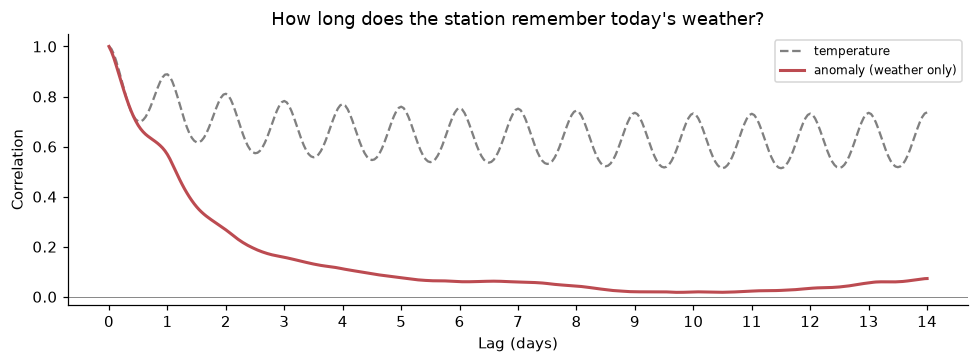

In [11]:
# Anomaly = temperature minus the average for that day of year and hour (smoothed over +-7 days)
day_of_year, hour = local.dayofyear.to_numpy(), local.hour.to_numpy()
normal = clean.groupby([day_of_year, hour])["temperature"].mean().unstack()
normal = pd.concat([normal.iloc[-7:], normal, normal.iloc[:7]]).rolling(15, center=True, min_periods=1).mean().iloc[7:-7]
anomaly = clean["temperature"] - normal.to_numpy()[day_of_year - 1, hour]

lags = np.arange(0, 14 * 24 + 1)
memory = pd.DataFrame({
    "temperature": [clean["temperature"].corr(clean["temperature"].shift(-k)) for k in lags],
    "anomaly (weather only)": [anomaly.corr(anomaly.shift(-k)) for k in lags],
}, index=lags)
print(memory.loc[[24, 72, 120, 168, 336]].rename(index=lambda k: f"{k // 24} days").round(2).T)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(lags / 24, memory["temperature"], color="grey", linestyle="--", label="temperature")
ax.plot(lags / 24, memory["anomaly (weather only)"], color="#bc4b51", linewidth=2, label="anomaly (weather only)")
ax.axhline(0, color="grey", linewidth=0.6)
ax.set(title="How long does the station remember today's weather?", xlabel="Lag (days)", ylabel="Correlation")
ax.set_xticks(range(15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "anomaly_memory")
plt.show()

### 5.3 How good is the raw ECMWF forecast?

Every 12z run is compared with the observations at the leads of the real task (17–352 h, i.e. forecast days 1–14). A report at hh:51 is matched with the forecast valid at hh+1:00 (checked in `01`). The historical average is computed from all years and is shown only as a reference line.

forecast_day          1     2     3     4     5     6     7     8     9     10    11    12    13    14
ECMWF raw forecast  1.58  1.69  1.84  1.98  2.11  2.46  2.80  3.12  3.31  3.71  4.12  4.19  4.34  4.69
historical average  3.68  3.68  3.68  3.68  3.68  3.68  3.68  3.68  3.69  3.75  3.78  3.79  3.79  3.79


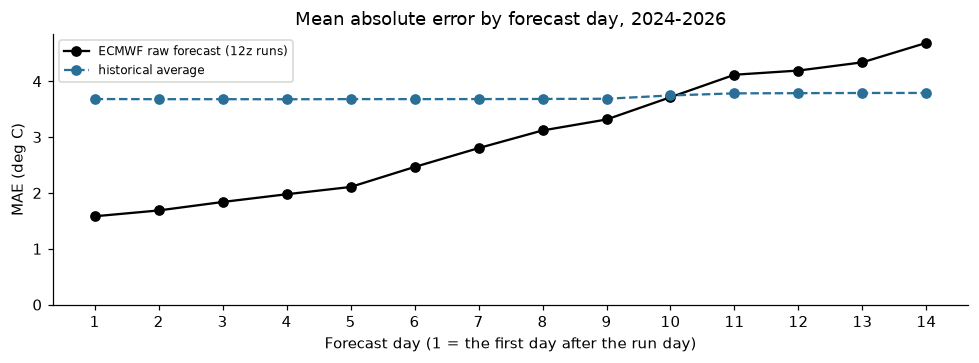

In [12]:
ecmwf = pd.read_csv(RAW_ECMWF, usecols=["run_utc", "valid_utc", "lead_hours", "temperature_2m"],
                    parse_dates=["run_utc", "valid_utc"])
ecmwf = ecmwf[ecmwf["run_utc"].dt.hour.eq(12)]  # 12z runs, as used for the real forecast
# A report at hh:51 is matched with the forecast valid at hh+1:00 (checked in 01)
report_hour = ecmwf["valid_utc"] - pd.Timedelta(hours=1)
ecmwf["observed"] = clean["temperature"].reindex(report_hour).to_numpy()
ecmwf["normal"] = (clean["temperature"] - anomaly).reindex(report_hour).to_numpy()
ecmwf = ecmwf[ecmwf["lead_hours"].between(17, 352)].dropna(subset=["observed"])  # leads of the Sep 17-30 window
ecmwf["forecast_day"] = (ecmwf["lead_hours"] - 17) // 24 + 1

skill = pd.DataFrame({
    "ECMWF raw forecast": (ecmwf["observed"] - ecmwf["temperature_2m"]).abs().groupby(ecmwf["forecast_day"]).mean(),
    "historical average": (ecmwf["observed"] - ecmwf["normal"]).abs().groupby(ecmwf["forecast_day"]).mean(),
})
print(skill.round(2).T)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(skill.index, skill["ECMWF raw forecast"], marker="o", color="black", label="ECMWF raw forecast (12z runs)")
ax.plot(skill.index, skill["historical average"], marker="o", color="#2a6f97", linestyle="--", label="historical average")
ax.set(title="Mean absolute error by forecast day, 2024-2026", xlabel="Forecast day (1 = the first day after the run day)",
       ylabel="MAE (deg C)", ylim=(0, None))
ax.set_xticks(range(1, 15))
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "ecmwf_skill_by_day")
plt.show()

### 5.4 Does ECMWF have a constant bias at RDU?

Mean of (observed − ECMWF) per month, for forecast days 1–3.

The bias is not constant. Until Jul 2025 the station reads about 1.3 °C warmer than ECMWF on average (0.9 to 2.2 °C by month); afterwards the gap is smaller: close to 0 in summer and autumn, 0.5 to 1.3 °C in winter. The checks in `docs/data_checks.md` (comparison with ERA5 and with nearby stations) point to a step in the **station's own readings around Jul 22, 2025** of about 1 °C, possibly a sensor replacement, rather than a change in ECMWF. Either way, the error to correct changes over time: this is why the model uses rolling biases over the last 14/30/60 days (`03`) and gives recent runs more weight (`04`).

valid_utc                         2024-03  2024-04  2024-05  2024-06  2024-07  2024-08  2024-09  2024-10  2024-11  2024-12  ...  2025-12  2026-01  2026-02  \
mean(observed - ECMWF), days 1-3     1.49     1.46     1.14     1.32     1.14     0.93      0.9     0.88     1.09     1.31  ...     0.47     0.88     1.31   

valid_utc                         2026-03  2026-04  2026-05  2026-06  2026-07  2026-08  2026-09  
mean(observed - ECMWF), days 1-3     0.96     0.12    -0.05    -0.09    -0.08     0.13     0.06  

[1 rows x 31 columns]
Mean bias before Jul 22, 2025: +1.31 deg C | after: +0.26 deg C


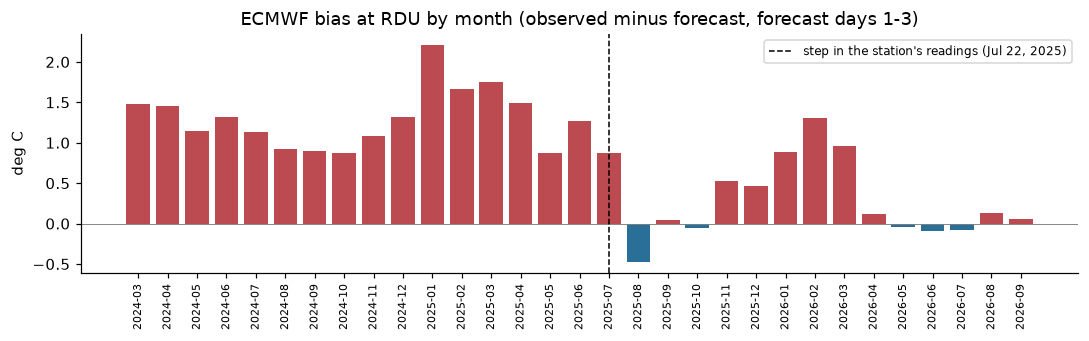

In [13]:
STATION_BREAK = pd.Timestamp("2025-07-22", tz=NY)  # step in the station's readings (docs/data_checks.md)
short_range = ecmwf[ecmwf["forecast_day"].le(3)]
error = short_range["observed"] - short_range["temperature_2m"]
bias = error.groupby(short_range["valid_utc"].dt.tz_convert(NY).dt.tz_localize(None).dt.to_period("M")).mean()
print(bias.round(2).to_frame("mean(observed - ECMWF), days 1-3").T)
after = short_range["valid_utc"] >= STATION_BREAK
print(f"Mean bias before Jul 22, 2025: {error[~after].mean():+.2f} deg C | after: {error[after].mean():+.2f} deg C")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(bias.index.astype(str), bias, color=np.where(bias > 0, "#bc4b51", "#2a6f97"))
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(list(bias.index).index(pd.Period(STATION_BREAK.strftime("%Y-%m"), "M")), color="black", linestyle="--",
           linewidth=1, label="step in the station's readings (Jul 22, 2025)")
ax.set(title="ECMWF bias at RDU by month (observed minus forecast, forecast days 1-3)", ylabel="deg C")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "ecmwf_bias_by_month")
plt.show()